# Small-Scale Unit Prediction

In order to better determine a method of attributing load and generation capacity to housing units, having a complete housing data frame with building footprint, housing atttributes from Zillow, and number of units is necessary. The following notebook contains data cleaning, joining, and prediction of number of housing units for observations for which that information is missing.

-----------------------------------------------------------

The parcel data we are working with is quite large, and therefore takes a very long time to load into notebooks. In order to more easily figure out our pipeline (without having to wait for it to load in each time), we will load only Los Angeles County, as it contains the arbitrary bbox we have chosen for our small-scale analysis.

The following notebook contains the following analysis:

1. Load in parcel, Zillow, and building footprint data.

**Account for missing, multi-family building data**

2. Select only Zillow observations that are categorized as multi-family homes.

3. Spatial join between parcel and multi-family Zillow data. Result: only residential parcels for multi-family homes.

4. Spatial join between residential parcels and building footprints. Result: only residential, multi-family home footprints.

**Predicting unit data**

5. Calculate building volume from footprint area and height.

6. Select only observations that have unit data.

7. Remove outliers based on residual size.

8. Regress building volume on number of housing units to determine relationship.

9. Use linear relationship to predict missing unit data.

**Address single family homes**

10. Spatial join between Zillow and single-family data, calculate volume.

**Final merge**

11. Concatenate complete multi-family data with residential single-family data.

## 1. Load in Data

In [1]:
# import necessary libraries
import pandas as pd
from shapely.geometry import box
import numpy as np
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import zipfile
import fiona
import pandas as pd

# statistical libraries
#import sys
#!{sys.executable} -m pip install statsmodels
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

ERROR 1: PROJ: proj_create_from_database: Open of /Users/sarak/.conda/envs/electrigrid-env/share/proj failed


In [2]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [3]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

### Parcel

Access: https://egis-lacounty.hub.arcgis.com/documents/baaf8251bfb94d3984fb58cb5fd93258/about 

In [4]:
# view layers within .gdb file
fiona.listlayers("data/Parcels_CA_2014.gdb")

['CA_PARCELS_STATEWIDE_INFO', 'CA_PARCELS_STATEWIDE']

In [5]:
# load parcels only for Los Angeles county (will take about 5 minutes)
parcels = gpd.read_file(
    "data/Parcels_CA_2014.gdb",
    layer="CA_PARCELS_STATEWIDE",
    where="County='Los Angeles'").to_crs(epsg=4326)

In [6]:
# check that data was loaded properly by plotting
# parcels.plot()

### Zillow 

Point data containing variables such housing type (single or multi-family) and number of housing units.

In [7]:
# import Zillow data (make take 10-20 minutes)
fp = os.path.join('data', 'final_zillow.gpkg')
zillow = gpd.read_file(fp).to_crs(epsg=4326)

### Building Footprint

There are a total of 8 parquet files that correspond to California. We select the one that contain Los Angeles county (w120_n35_w115_n30.parquet).

Access: https://sat-io.earthengine.app/view/gba

In [8]:
# import building footprint as geopandas dataframe (may take 1-5 minutes)
fp = os.path.join('data', 'building_parquets', 'w120_n35_w115_n30.parquet')
building = gpd.read_parquet(fp).to_crs(epsg=4326)

## Account for Missing Multi-Family Data
#### Steps 1-4

A simple join between Zillow points and building footprints resulted in missing data, particularly with observations that were identified as multi-family. This is because multi-family housing complexes are often dispersed/made up of multiple buildings, meaning the Zillow points don't always match up to the footprint polygons.

Introducing parcel data solves this issue as it is a larger area, and guarantees that the Zillow point will be in the appropriate parcel. 

In [9]:
# familiarize ourselves with data
zillow.head(3)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry
0,Multi,2003.0,1.0,None,None,I,224.0,491943.0,living,1003.0,3,06001403302,468,PGE/SCE,RR106,POINT (-122.26800 37.79429)
1,Multi,2003.0,1.0,None,None,None,224.0,240117.0,living,936.0,4,06001403302,468,PGE/SCE,RR106,POINT (-122.26800 37.79429)
2,Multi,2003.0,1.0,None,None,I,224.0,261770.0,living,997.0,5,06001403302,468,PGE/SCE,RR106,POINT (-122.26800 37.79429)


In [10]:
# 2. select only multi-family data
zillow_multi = zillow[zillow['type'] == "Multi"]
zillow_multi = zillow_multi[zillow_multi['code'] != "RR106"]

zillow_multi.head(3)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry
15,Multi,1906.0,4.0,None,None,None,2.0,341342.0,living,1260.0,27,06001982000,468,PGE/SCE,RI101,POINT (-122.28208 37.80073)
17,Multi,1910.0,6.0,None,None,None,3.0,NaN,living,2561.0,34,06001982000,468,PGE/SCE,RI102,POINT (-122.28200 37.80028)
59,Multi,2020.0,NaN,None,None,None,134.0,81712772.0,living,140806.0,185,06001983200,468,PGE/SCE,RI104,POINT (-122.27484 37.79503)


In [11]:
# 3. crop to residential parcels (by keeping those with Zillow points within)

# keep the indices where multi-family homes match to parcels
valid_parcels = parcels.sjoin(zillow_multi, predicate="contains").index.unique()

# select the parcels that match these indices
parcels_res = parcels.loc[valid_parcels]

In [12]:
# result = parcels with multi-family homes as observations
parcels_res.head(3)

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,geometry
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,..."
1043,7025021049,Los Angeles,None,None,None,425.387015,3342.792009,"MULTIPOLYGON Z (((-118.07031 33.86931 0.00000,..."
1296,7025026019,Los Angeles,None,None,None,131.706966,1036.902557,"MULTIPOLYGON Z (((-118.07190 33.86751 0.00000,..."


In [13]:
# confirm that joining with Zillow decreased the number of parcels
print(f"Original parcel rows: {len(parcels)}")
print(f"Residential parcel rows: {len(parcels_res)}")
print(f"There are less residential parcels than total parcels: {len(parcels_res) < len(parcels)}")

Original parcel rows: 2389138
Residential parcel rows: 245561
There are less residential parcels than total parcels: True


In [14]:
# 4. crop to residential buildings (by keeping only those within residential parcels)
valid_buildings = building.sjoin(parcels_res, predicate="intersects").index.unique()
buildings_res = building.loc[valid_buildings]

In [15]:
buildings_res.head(3)

,source,id,height,var,region,bbox,geometry
1199366,osm,470435170,4.024961,0.620044,USA,"{'xmin': -117.7061048, 'ymin': 34.095258499999...","POLYGON ((-117.70610 34.09536, -117.70601 34.0..."
1199367,osm,470435165,4.172357,0.215071,USA,"{'xmin': -117.70619690000001, 'ymin': 34.09533...","POLYGON ((-117.70612 34.09534, -117.70620 34.0..."
1199369,osm,470435162,6.822182,1.606937,USA,"{'xmin': -117.7064271, 'ymin': 34.095364, 'xma...","POLYGON ((-117.70635 34.09537, -117.70642 34.0..."


In [16]:
## join parcels to buildings (keeping observations as parcels, but with building attributes)
# sum number of units per parcel
units_sum = parcels_res.sjoin(zillow_multi, predicate="intersects").groupby(level=0)["unit"].sum()

# join on parcels with summed number of units
parcels_res = parcels_res.join(units_sum)

In [17]:
parcels_res.head(3)

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,geometry,unit
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,...",3.0
1043,7025021049,Los Angeles,None,None,None,425.387015,3342.792009,"MULTIPOLYGON Z (((-118.07031 33.86931 0.00000,...",4.0
1296,7025026019,Los Angeles,None,None,None,131.706966,1036.902557,"MULTIPOLYGON Z (((-118.07190 33.86751 0.00000,...",2.0


In [18]:
# confirm that joining with Zillow decreased the number of parcels
print(f"Original building rows: {len(building)}")
print(f"Residential building rows: {len(buildings_res)}")
print(f"There are less residential buildings than total total: {len(buildings_res) < len(building)}")

Original building rows: 9503685
Residential building rows: 595878
There are less residential buildings than total total: True


In [19]:
# keep all residential buildings, and add zillow points only where they match up
building_zillow = gpd.sjoin(
    buildings_res,
    zillow_multi,
    how = "left",
    predicate = "intersects")

In [20]:
# confirm that at least some buildings have Zillow data
building_zillow[~building_zillow['unit'].isna()].head(3)

,source,id,height,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code
1199394,osm,470435154,4.898030,0.318184,USA,"{'xmin': -117.7049224, 'ymin': 34.095399400000...","POLYGON ((-117.70479 34.09554, -117.70481 34.0...",2747575.0,Multi,NaN,4.0,None,central,None,2.0,292666.0,living,2129.0,4033224.0,06037401901,1327,PGE/SCE,RI101
1199414,osm,470435140,3.046337,0.290904,USA,"{'xmin': -117.7049412, 'ymin': 34.0958166, 'xm...","POLYGON ((-117.70484 34.09582, -117.70486 34.0...",2532297.0,Multi,NaN,3.0,None,None,None,2.0,45408.0,living,1456.0,3787338.0,06037401901,1327,PGE/SCE,RI101
1199416,osm,470435136,6.251768,0.752298,USA,"{'xmin': -117.704726, 'ymin': 34.0958261, 'xma...","POLYGON ((-117.70468 34.09601, -117.70465 34.0...",2747574.0,Multi,NaN,4.0,None,central,None,2.0,475673.0,living,2088.0,4033223.0,06037401901,1327,PGE/SCE,RI101


## Predicting Unit Data

#### 5. Find building volume

In [21]:
# reproject data frame to crs with meters as units
building_m = building_zillow.to_crs("EPSG:6933")

In [22]:
# create column from polygon area
building_m['area_m2'] = building_m.geometry.area

# rename height column to be clear about units
building_m.rename(columns={"height":"height_m"}, inplace = True)

building_m.head(2)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2
1199366,osm,470435170,4.024961,0.620044,USA,"{'xmin': -117.7061048, 'ymin': 34.095258499999...","POLYGON ((-11357024.215 4103208.262, -11357015...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.958599
1199367,osm,470435165,4.172357,0.215071,USA,"{'xmin': -117.70619690000001, 'ymin': 34.09533...","POLYGON ((-11357025.797 4103205.345, -11357032...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.752743


In [23]:
# create volume column
building_m['volume_m3'] = building_m['area_m2'] * building_m['height_m']

building_m.head(2)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3
1199366,osm,470435170,4.024961,0.620044,USA,"{'xmin': -117.7061048, 'ymin': 34.095258499999...","POLYGON ((-11357024.215 4103208.262, -11357015...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.958599,398.304455
1199367,osm,470435165,4.172357,0.215071,USA,"{'xmin': -117.70619690000001, 'ymin': 34.09533...","POLYGON ((-11357025.797 4103205.345, -11357032...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.752743,228.447967


In [24]:
# explore number of rows that don't have unit data -- it's a lot
building_m['unit'].isna().sum()

431689

In [25]:
# 6. keep only observations with unit data
building_w_units = building_m[~building_m['unit'].isna()]

# confirm operation worked
building_w_units['unit'].isna().sum()

0

<Axes: xlabel='volume_m3', ylabel='unit'>

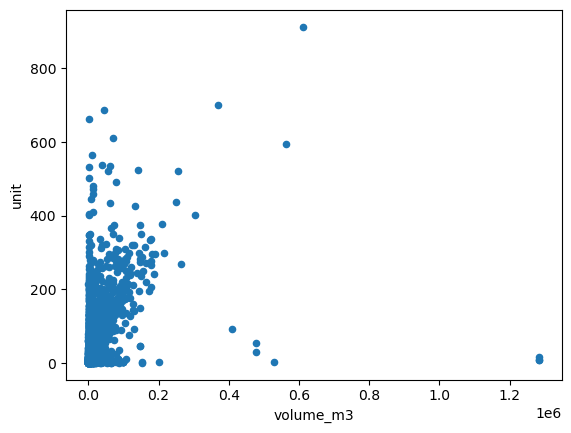

In [26]:
# plot units vs volume^3
building_w_units.plot(kind='scatter',
              x='volume_m3', 
              y='unit')

#### 7. Remove outliers based on residual size 

In [27]:
# run model
results = smf.ols('unit ~ volume_m3', data=building_w_units).fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   unit   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                 4.530e+04
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:56:06   Log-Likelihood:            -6.5484e+05
No. Observations:              165363   AIC:                         1.310e+06
Df Residuals:                  165361   BIC:                         1.310e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3850      0.032    136.590      0.0

In [28]:
# add residuals as a column
building_w_units['residual'] = results.resid.copy()
building_w_units.head(2)

/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3,residual
1199394,osm,470435154,4.898030,0.318184,USA,"{'xmin': -117.7049224, 'ymin': 34.095399400000...","POLYGON ((-11356897.258 4103226.701, -11356899...",2747575.0,Multi,NaN,4.0,None,central,None,2.0,292666.0,living,2129.0,4033224.0,06037401901,1327,PGE/SCE,RI101,201.642897,987.653018,-3.217763
1199414,osm,470435140,3.046337,0.290904,USA,"{'xmin': -117.7049412, 'ymin': 34.0958166, 'xm...","POLYGON ((-11356902.440 4103256.406, -11356904...",2532297.0,Multi,NaN,3.0,None,None,None,2.0,45408.0,living,1456.0,3787338.0,06037401901,1327,PGE/SCE,RI101,82.978578,252.780743,-2.598131


In [29]:
# keep only observations that are less/equal to 2 standard deviations from residuals
building_units_clean = building_w_units[building_w_units['residual'].abs() <= 2 * building_w_units['residual'].std()]

building_units_clean.head(2)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3,residual
1199394,osm,470435154,4.898030,0.318184,USA,"{'xmin': -117.7049224, 'ymin': 34.095399400000...","POLYGON ((-11356897.258 4103226.701, -11356899...",2747575.0,Multi,NaN,4.0,None,central,None,2.0,292666.0,living,2129.0,4033224.0,06037401901,1327,PGE/SCE,RI101,201.642897,987.653018,-3.217763
1199414,osm,470435140,3.046337,0.290904,USA,"{'xmin': -117.7049412, 'ymin': 34.0958166, 'xm...","POLYGON ((-11356902.440 4103256.406, -11356904...",2532297.0,Multi,NaN,3.0,None,None,None,2.0,45408.0,living,1456.0,3787338.0,06037401901,1327,PGE/SCE,RI101,82.978578,252.780743,-2.598131


In [30]:
# save outliers, as we will re-predict them using the regression
building_outliers = building_w_units[building_w_units['residual'].abs() > 2 * building_w_units['residual'].std()]

#### 8. Regress building volume on number of housing units to determine relationship.

In [31]:
# rerun linear regression
results_clean = smf.ols('unit ~ volume_m3', data=building_units_clean).fit()

# save variables
intercept = results_clean.params[0]
slope = results_clean.params[1]

/tmp/ipykernel_858757/3412973521.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results_clean.params[0]
/tmp/ipykernel_858757/3412973521.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results_clean.params[1]


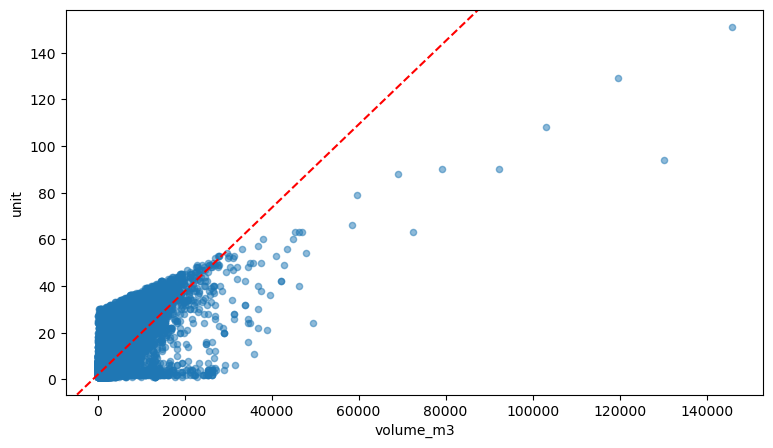

In [32]:
fig, ax = plt.subplots(figsize=(9,5), nrows = 1, ncols = 1)

# plot -- looks exactly the same as before 
building_units_clean.plot(ax=ax,
                            kind='scatter',
                            x='volume_m3', 
                            y='unit',
                          alpha = 0.5)

ax.axline(xy1=(0, intercept), slope=slope, color='r', linestyle='--', label=f'y = {slope}x + {intercept}')

#### 9. Add unit info for multi-family homes where it is missing

In [33]:
# extract just the multi-family homes where unit info is missing
missing_units = building_m[building_m['unit'].isna()]

missing_units.head(3)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3
1199366,osm,470435170,4.024961,0.620044,USA,"{'xmin': -117.7061048, 'ymin': 34.095258499999...","POLYGON ((-11357024.215 4103208.262, -11357015...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.958599,398.304455
1199367,osm,470435165,4.172357,0.215071,USA,"{'xmin': -117.70619690000001, 'ymin': 34.09533...","POLYGON ((-11357025.797 4103205.345, -11357032...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.752743,228.447967
1199369,osm,470435162,6.822182,1.606937,USA,"{'xmin': -117.7064271, 'ymin': 34.095364, 'xma...","POLYGON ((-11357048.288 4103208.559, -11357055...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.934800,306.553391


In [34]:
# combine dataframes with missing unit data as well as outliers (since both will be predicted)
missing_outlier_units = pd.concat([building_outliers, missing_units])

# make sure concat worked 
print(f"Total rows of missing units: {len(missing_units)}")
print(f"Total rows combined dataframe: {len(missing_outlier_units)}")

Total rows of missing units: 431689
Total rows combined dataframe: 434444


In [35]:
# replace unit column with prediction
missing_outlier_units_pred = missing_outlier_units.copy().drop('unit', axis = 1)

# round, as units can't be decimels


In [36]:
missing_outlier_units_pred = missing_outlier_units_pred.reset_index(drop=True)

missing_outlier_units_pred.head(3)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3,residual
0,osm,470255229,5.539608,0.669596,USA,"{'xmin': -117.7040794, 'ymin': 34.1086662, 'xm...","POLYGON ((-11356825.916 4104660.382, -11356826...",2529601.0,Multi,NaN,NaN,None,central,None,13692134.0,living,137156.0,3784350.0,06037401801,1327,PGE/SCE,RI104,664.410304,3680.572317,192.511611
1,osm,470279089,3.173640,0.469443,USA,"{'xmin': -117.74604400000001, 'ymin': 34.10916...","POLYGON ((-11360874.847 4104676.102, -11360876...",2527266.0,Multi,NaN,NaN,None,None,None,3701202.0,living,4354.0,3781926.0,06037401705,1125,PGE/SCE,RI109,131.199645,416.380505,137.263924
2,osm,470283564,6.062890,1.005159,USA,"{'xmin': -117.74839800000001, 'ymin': 34.10433...","POLYGON ((-11361104.929 4104160.127, -11361104...",2554503.0,Multi,NaN,NaN,None,None,None,2342533.0,living,47394.0,3811693.0,06037401707,1125,PGE/SCE,RI104,319.573666,1937.539846,37.981308


In [37]:
missing_outlier_units_pred['unit'] = round(intercept + missing_outlier_units_pred['volume_m3'] * slope)

missing_outlier_units_pred.head(3)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3,residual,unit
0,osm,470255229,5.539608,0.669596,USA,"{'xmin': -117.7040794, 'ymin': 34.1086662, 'xm...","POLYGON ((-11356825.916 4104660.382, -11356826...",2529601.0,Multi,NaN,NaN,None,central,None,13692134.0,living,137156.0,3784350.0,06037401801,1327,PGE/SCE,RI104,664.410304,3680.572317,192.511611,9.0
1,osm,470279089,3.173640,0.469443,USA,"{'xmin': -117.74604400000001, 'ymin': 34.10916...","POLYGON ((-11360874.847 4104676.102, -11360876...",2527266.0,Multi,NaN,NaN,None,None,None,3701202.0,living,4354.0,3781926.0,06037401705,1125,PGE/SCE,RI109,131.199645,416.380505,137.263924,3.0
2,osm,470283564,6.062890,1.005159,USA,"{'xmin': -117.74839800000001, 'ymin': 34.10433...","POLYGON ((-11361104.929 4104160.127, -11361104...",2554503.0,Multi,NaN,NaN,None,None,None,2342533.0,living,47394.0,3811693.0,06037401707,1125,PGE/SCE,RI104,319.573666,1937.539846,37.981308,5.0


In [38]:
# view
# missing_outlier_units_pred.plot(kind='scatter',
#                             x='volume_m3', 
#                             y='unit')

## Address Single Family Homes
#### 11. Temporarily combine different housing types back into one dataframe

In [40]:
# combine multi-family homes data frames
multi_complete = pd.concat([building_w_units, missing_outlier_units_pred]).to_crs(zillow.crs)

# drop residual column
multi_complete = multi_complete.drop(['residual'], axis = 1)

multi_complete.head(3)

,source,id,height_m,var,region,bbox,geometry,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3
1199394,osm,470435154,4.898030,0.318184,USA,"{'xmin': -117.7049224, 'ymin': 34.095399400000...","POLYGON ((-117.70479 34.09554, -117.70481 34.0...",2747575.0,Multi,NaN,4.0,None,central,None,2.0,292666.0,living,2129.0,4033224.0,06037401901,1327,PGE/SCE,RI101,201.642897,987.653018
1199414,osm,470435140,3.046337,0.290904,USA,"{'xmin': -117.7049412, 'ymin': 34.0958166, 'xm...","POLYGON ((-117.70484 34.09582, -117.70486 34.0...",2532297.0,Multi,NaN,3.0,None,None,None,2.0,45408.0,living,1456.0,3787338.0,06037401901,1327,PGE/SCE,RI101,82.978578,252.780743
1199416,osm,470435136,6.251768,0.752298,USA,"{'xmin': -117.704726, 'ymin': 34.0958261, 'xma...","POLYGON ((-117.70468 34.09601, -117.70465 34.0...",2747574.0,Multi,NaN,4.0,None,central,None,2.0,475673.0,living,2088.0,4033223.0,06037401901,1327,PGE/SCE,RI101,226.620097,1416.776185


## Explore multi-family homes as parcels option

In [41]:
parcels_res.head(3)

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,geometry,unit
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,...",3.0
1043,7025021049,Los Angeles,None,None,None,425.387015,3342.792009,"MULTIPOLYGON Z (((-118.07031 33.86931 0.00000,...",4.0
1296,7025026019,Los Angeles,None,None,None,131.706966,1036.902557,"MULTIPOLYGON Z (((-118.07190 33.86751 0.00000,...",2.0


In [42]:
multi_complete = multi_complete.drop(['index_right'], axis = 1)

In [44]:
multi_by_parcel = parcels_res.sjoin(multi_complete, predicate="intersects")

len(multi_by_parcel)

751424

In [45]:
# here, parcels are the unit of observation
# if there are three buildings per parcel, there are now three rows for that one parcel (with each buildings attributes)
multi_by_parcel.head(3)

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,geometry,unit_left,index_right,source,id,height_m,var,region,bbox,type,year,room,heat,cool,own,unit_right,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,area_m2,volume_m3
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,...",3.0,371002,ms,UnitedStates_023013200_1280037,3.942353,0.920224,USA,"{'xmin': -118.072166849672, 'ymin': 33.8676641...",NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,297.252062,1171.872631
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,...",3.0,4425363,ms,UnitedStates_023013200_852984,3.935684,0.976993,USA,"{'xmin': -118.07219705294985, 'ymin': 33.86783...",Multi,NaN,7.0,None,None,O,3.0,487155.0,living,3039.0,3352737.0,06037554802,957,PGE/SCE,RI102,278.252596,1095.114415
969,7025021043,Los Angeles,None,None,None,109.330222,716.550267,"MULTIPOLYGON Z (((-118.07195 33.86787 0.00000,...",3.0,371005,ms,UnitedStates_023013200_1007396,3.602288,0.987792,USA,"{'xmin': -118.07234536803664, 'ymin': 33.86788...",NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.593030,582.104671


In [50]:
print(parcels_res.sjoin(multi_complete, predicate="intersects").columns.tolist())

['PARNO', 'County', 'ADDRESS', 'CITY', 'ZIP', 'Shape_Length', 'Shape_Area', 'geometry', 'unit_left', 'index_right', 'source', 'id', 'height_m', 'var', 'region', 'bbox', 'type', 'year', 'room', 'heat', 'cool', 'own', 'unit_right', 'value', 'sqft_type', 'sqft', 'ID', 'GEOID', 'p_ID', 'area', 'code', 'area_m2', 'volume_m3']


In [52]:
# join back to parcels
units_multi = parcels_res.sjoin(multi_complete, predicate="intersects").groupby(level=0)['unit_right'].sum()

# join on parcels with summed number of units
multi_summed_units = parcels_res.join(units_multi)

len(multi_summed_units) # should be shorter than `multi_by_parcel`

245561

In [ ]:
multi_summed_units.head(3)

In [53]:
# save all non-multi observations
non_multi = building_m[building_m['type'] != "Multi"].to_crs(zillow.crs)

# keep only variables of interest
non_multi = non_multi[['source', 'id', 'height_m', 'var', 'region', 'bbox', 'geometry', 'area_m2', 'volume_m3']]

non_multi.head(3)

,source,id,height_m,var,region,bbox,geometry,area_m2,volume_m3
1199366,osm,470435170,4.024961,0.620044,USA,"{'xmin': -117.7061048, 'ymin': 34.095258499999...","POLYGON ((-117.70610 34.09536, -117.70601 34.0...",98.958599,398.304455
1199367,osm,470435165,4.172357,0.215071,USA,"{'xmin': -117.70619690000001, 'ymin': 34.09533...","POLYGON ((-117.70612 34.09534, -117.70620 34.0...",54.752743,228.447967
1199369,osm,470435162,6.822182,1.606937,USA,"{'xmin': -117.7064271, 'ymin': 34.095364, 'xma...","POLYGON ((-117.70635 34.09537, -117.70642 34.0...",44.934800,306.553391


In [54]:
# join Zillow data to non-multi family homes (takes ~1 minute)
non_multi_points = gpd.sjoin(
    zillow, # left df's geometry is always kept
    non_multi,
    how = "inner",
    predicate = "intersects")

non_multi_points.head(3)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry,index_right,source,id,height_m,var,region,bbox,area_m2,volume_m3
1507093,Single,NaN,2.0,fossil,central,None,1.0,623376.0,living,2068.0,1832422,06037113235,867,PGE/SCE,RR101,POINT (-118.63423 34.23825),3472683,osm,430092820,3.276308,0.287980,USA,"{'xmin': -118.63428550000002, 'ymin': 34.23819...",119.094492,390.190188
1526714,Single,NaN,3.0,elec,None,I,1.0,222800.0,living,1365.0,2079237,06037320101,1330,PGE/SCE,RR101,POINT (-118.42660 34.29917),2160071,osm,438853284,3.122706,0.121397,USA,"{'xmin': -118.42671879999999, 'ymin': 34.29909...",244.711315,764.161476
1526720,Single,NaN,5.0,fossil,central,O,1.0,363889.0,living,1622.0,2079259,06037320102,1330,PGE/SCE,RR101,POINT (-118.42522 34.29785),2160331,osm,430546854,4.087214,0.343873,USA,"{'xmin': -118.42538250000001, 'ymin': 34.29775...",323.090287,1320.539295


In [55]:
non_multi_footprints = gpd.sjoin(
    non_multi,
    zillow,
    how = "inner",
    predicate = "intersects")

non_multi_footprints.head(3)

,source,id,height_m,var,region,bbox,geometry,area_m2,volume_m3,index_right,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code
1199738,osm,470362133,4.990118,0.663813,USA,"{'xmin': -117.71709560000001, 'ymin': 34.10117...","POLYGON ((-117.71709 34.10122, -117.71710 34.1...",269.181796,1343.248934,2530755,Single,NaN,8.0,fossil,central,None,1.0,383123.0,living,4238.0,3785575,06037401902,1327,PGE/SCE,RR101
1200004,osm,470362019,5.000665,0.408615,USA,"{'xmin': -117.7156016, 'ymin': 34.1023277, 'xm...","POLYGON ((-117.71558 34.10242, -117.71560 34.1...",196.005483,980.157796,2530654,Single,NaN,2.0,fossil,None,None,1.0,577340.0,living,1360.0,3785473,06037401902,1327,PGE/SCE,RR101
1202783,osm,470255235,4.190982,0.291885,USA,"{'xmin': -117.70333099999998, 'ymin': 34.10987...","POLYGON ((-117.70318 34.10988, -117.70329 34.1...",273.093355,1144.529429,2530008,Single,NaN,3.0,fossil,None,None,1.0,532877.0,living,1670.0,3784767,06037401801,1327,PGE/SCE,RR101


In [ ]:
# combine
#building_complete = pd.concat([multi_complete, non_multi_zillow])

#building_complete[building_complete['type'] == "Single"].head(3)

## Save as GeoJSON file

This takes about 

In [ ]:
# building_complete.to_file("data/building_complete.geojson", driver='GeoJSON')

Multi-family homes, with parcels as observations and summed units:

In [56]:
multi_summed_units.to_file("data/multi_summed_units.geojson", driver='GeoJSON')

Multi-family homes, with parcels as observations BUT multiple observations for the same parcel if there are multiple buildings inside of it.

In [57]:
multi_by_parcel.to_file("data/multi_by_parcel.geojson", driver='GeoJSON')

Non-multi family houses, with the geometries as Zillow points

In [58]:
non_multi_points.to_file("data/non_multi_zillow.geojson", driver='GeoJSON')